<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

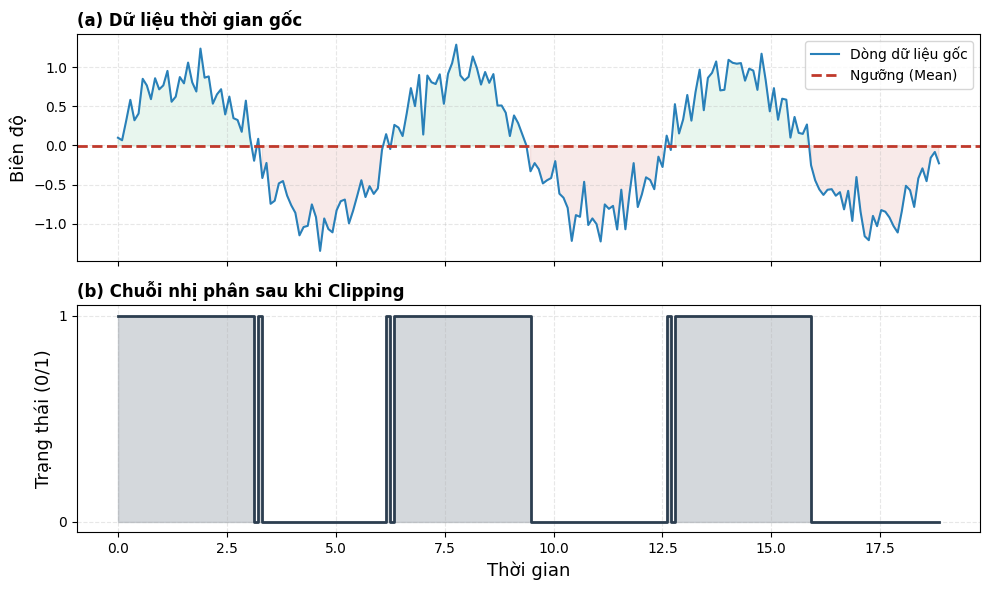

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. TẠO DỮ LIỆU GIẢ LẬP
np.random.seed(42)
t = np.linspace(0, 6 * np.pi, 200)
raw_data = np.sin(t) + np.random.normal(0, 0.2, len(t))

# 2. THỰC HIỆN KỸ THUẬT CLIPPING
threshold = np.mean(raw_data)
binary_data = np.where(raw_data > threshold, 1, 0)

# 3. VẼ BIỂU ĐỒ
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# --- BIỂU ĐỒ A: DỮ LIỆU THÔ ---
ax1.plot(t, raw_data, color='#2980B9', label='Dòng dữ liệu gốc', linewidth=1.5)
ax1.axhline(y=threshold, color='#C0392B', linestyle='--', linewidth=2, label='Ngưỡng (Mean)')
ax1.fill_between(t, raw_data, threshold, where=(raw_data > threshold), color='#27AE60', alpha=0.1)
ax1.fill_between(t, raw_data, threshold, where=(raw_data <= threshold), color='#C0392B', alpha=0.1)

ax1.set_title('(a) Dữ liệu thời gian gốc', fontsize=12, fontweight='bold', loc='left')
ax1.set_ylabel('Biên độ', fontsize=13)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3, linestyle='--')

# --- BIỂU ĐỒ B: CHUỖI BIT SAU KHI CLIPPING ---
ax2.step(t, binary_data, where='post', color='#2C3E50', linewidth=2, label='Bit String')
ax2.fill_between(t, binary_data, step="post", alpha=0.2, color='#2C3E50')

ax2.set_title('(b) Chuỗi nhị phân sau khi Clipping', fontsize=12, fontweight='bold', loc='left')
ax2.set_xlabel('Thời gian', fontsize=13)
ax2.set_ylabel('Trạng thái (0/1)', fontsize=13)
ax2.set_yticks([0, 1])
ax2.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()

plt.savefig('Fig_03_Clipping.png', dpi=300, bbox_inches='tight')

try:
    from google.colab import files
    files.download('Fig_03_Clipping.png')
except ImportError:
    pass

plt.show()

--- KẾT QUẢ TRÍCH XUẤT ĐẶC TRƯNG ---
Thiết bị A (Gốc: 200 điểm) -> Đặc trưng: {'Mean': np.float64(219.91845806965583), 'Std_Dev': np.float64(1.857346977470942)}
Thiết bị B (Gốc: 200 điểm) -> Đặc trưng: {'Mean': np.float64(221.2880228034832), 'Std_Dev': np.float64(14.76799814058644)}


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

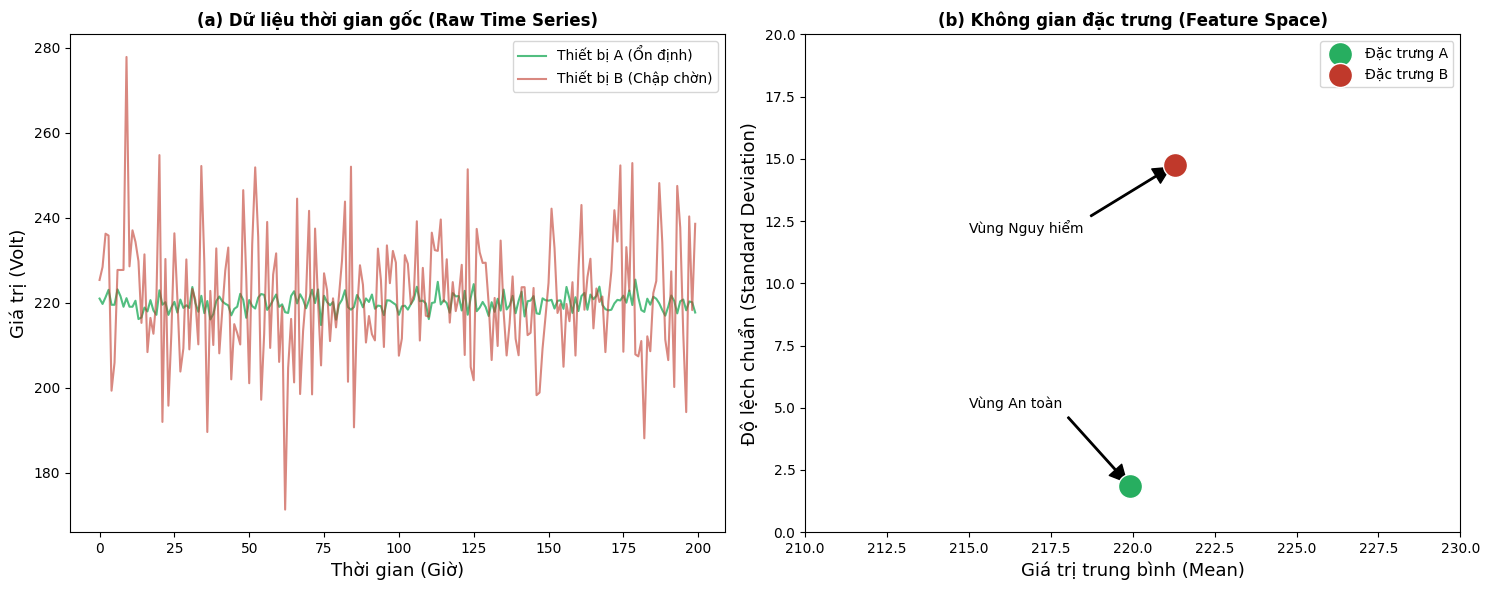

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. TẠO DỮ LIỆU THỜI GIAN GỐC (RAW DATA)
# ==========================================
np.random.seed(42)
t = np.arange(200) # 200 mốc thời gian

# Thiết bị A: Hoạt động ổn định (Trung bình 220V, lệch ít 2V)
data_a = np.random.normal(220, 2, 200)

# Thiết bị B: Hoạt động chập chờn (Trung bình 220V, nhưng lệch rất mạnh 15V)
data_b = np.random.normal(220, 15, 200)

# ==========================================
# 2. ÁP DỤNG KỸ THUẬT 1: FEATURE EXTRACTION
# (Biến đổi chuỗi 200 chiều -> Vector 2 chiều)
# ==========================================
def extract_frequency_features(data):
    return {
        'Mean': np.mean(data),
        'Std_Dev': np.std(data)
    }

features_a = extract_frequency_features(data_a)
features_b = extract_frequency_features(data_b)

# In kết quả dạng số để thấy sự "nén" dữ liệu
print("--- KẾT QUẢ TRÍCH XUẤT ĐẶC TRƯNG ---")
print(f"Thiết bị A (Gốc: 200 điểm) -> Đặc trưng: {features_a}")
print(f"Thiết bị B (Gốc: 200 điểm) -> Đặc trưng: {features_b}")

# ==========================================
# 3. TRỰC QUAN HÓA
# ==========================================
plt.style.use('default')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# --- Biểu đồ 1: Dữ liệu thời gian gốc ---
ax1.plot(t, data_a, color='#27AE60', label='Thiết bị A (Ổn định)', alpha=0.8)
ax1.plot(t, data_b, color='#C0392B', label='Thiết bị B (Chập chờn)', alpha=0.6)
ax1.set_title('(a) Dữ liệu thời gian gốc (Raw Time Series)', fontweight='bold')
ax1.set_xlabel('Thời gian (Giờ)', fontsize=13)
ax1.set_ylabel('Giá trị (Volt)', fontsize=13)
ax1.legend()

# --- Biểu đồ 2: Không gian đặc trưng (Kết quả sau kỹ thuật 1) ---
ax2.scatter(features_a['Mean'], features_a['Std_Dev'], color='#27AE60', s=300, label='Đặc trưng A', edgecolors='white', zorder=5)
ax2.scatter(features_b['Mean'], features_b['Std_Dev'], color='#C0392B', s=300, label='Đặc trưng B', edgecolors='white', zorder=5)

# Vẽ mũi tên minh họa sự biến đổi (Nén dữ liệu)
ax2.annotate('Vùng An toàn', xy=(features_a['Mean'], features_a['Std_Dev']), xytext=(215, 5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1), fontsize=10)
ax2.annotate('Vùng Nguy hiểm', xy=(features_b['Mean'], features_b['Std_Dev']), xytext=(215, 12),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1), fontsize=10)

ax2.set_title('(b) Không gian đặc trưng (Feature Space)', fontweight='bold')
ax2.set_xlabel('Giá trị trung bình (Mean)', fontsize=13)
ax2.set_ylabel('Độ lệch chuẩn (Standard Deviation)', fontsize=13)
ax2.set_xlim(210, 230)
ax2.set_ylim(0, 20)
ax2.legend()

plt.tight_layout()

plt.savefig('Fig_04_Freq', dpi=300, bbox_inches='tight')

try:
    from google.colab import files
    files.download('Fig_04_Freq.png')
except ImportError:
    pass

plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

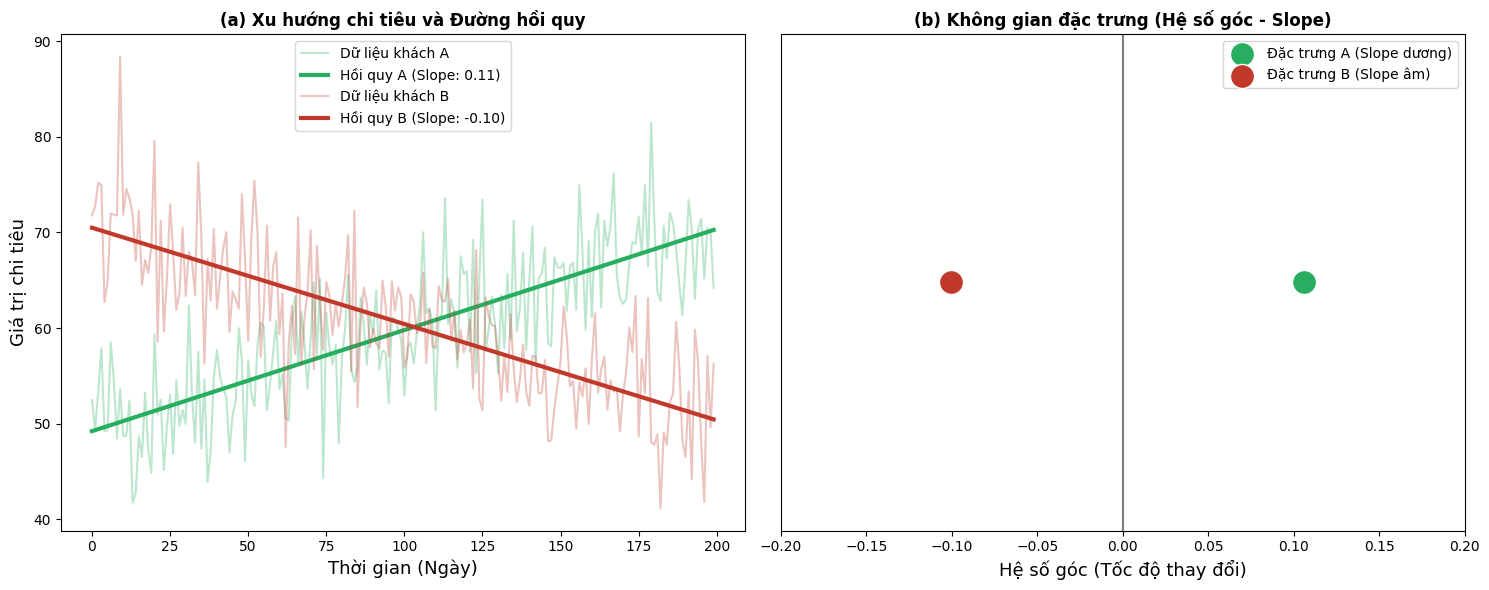

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. TẠO DỮ LIỆU THỜI GIAN (XU HƯỚNG TĂNG/GIẢM)
# ==========================================
np.random.seed(42)
t = np.arange(200)

# Khách hàng A: Chi tiêu tăng dần (Slope dương)
# y = 0.1t + 50 + noise
data_a = 0.1 * t + 50 + np.random.normal(0, 5, 200)

# Khách hàng B: Chi tiêu giảm dần (Slope âm)
# y = -0.1t + 70 + noise
data_b = -0.1 * t + 70 + np.random.normal(0, 5, 200)

# ==========================================
# 2. TRÍCH XUẤT ĐẶC TRƯNG HỒI QUY (SLOPE)
# ==========================================
# Sử dụng polyfit bậc 1 để tìm hệ số góc (slope)
slope_a, intercept_a = np.polyfit(t, data_a, 1)
slope_b, intercept_b = np.polyfit(t, data_b, 1)

# Đường hồi quy để vẽ minh họa
reg_line_a = slope_a * t + intercept_a
reg_line_b = slope_b * t + intercept_b

# ==========================================
# 3. TRỰC QUAN HÓA
# ==========================================
plt.style.use('default')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# --- Biểu đồ A: Dữ liệu thời gian và đường hồi quy ---
ax1.plot(t, data_a, color='#27AE60', alpha=0.3, label='Dữ liệu khách A')
ax1.plot(t, reg_line_a, color='#27AE60', linewidth=3, label=f'Hồi quy A (Slope: {slope_a:.2f})')

ax1.plot(t, data_b, color='#C0392B', alpha=0.3, label='Dữ liệu khách B')
ax1.plot(t, reg_line_b, color='#C0392B', linewidth=3, label=f'Hồi quy B (Slope: {slope_b:.2f})')

ax1.set_title('(a) Xu hướng chi tiêu và Đường hồi quy', fontweight='bold')
ax1.set_xlabel('Thời gian (Ngày)',fontsize=13)
ax1.set_ylabel('Giá trị chi tiêu', fontsize=13)
ax1.legend()

# --- Biểu đồ B: Không gian đặc trưng Slope ---
ax2.scatter(slope_a, 0, color='#27AE60', s=300, label='Đặc trưng A (Slope dương)', edgecolors='white', zorder=5)
ax2.scatter(slope_b, 0, color='#C0392B', s=300, label='Đặc trưng B (Slope âm)', edgecolors='white', zorder=5)

# Vẽ trục tọa độ trung tâm cho rõ rệt
ax2.axvline(x=0, color='black', linestyle='-', alpha=0.5)
ax2.set_title('(b) Không gian đặc trưng (Hệ số góc - Slope)', fontweight='bold')
ax2.set_xlabel('Hệ số góc (Tốc độ thay đổi)', fontsize=13)
ax2.set_yticks([]) # Ẩn trục Y vì ta chỉ quan tâm Slope trên trục X
ax2.set_xlim(-0.2, 0.2)
ax2.legend()

plt.tight_layout()
plt.savefig('Fig_05_Reg', dpi=300, bbox_inches='tight')

try:
    from google.colab import files
    files.download('Fig_05_Reg.png')
except ImportError:
    pass
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

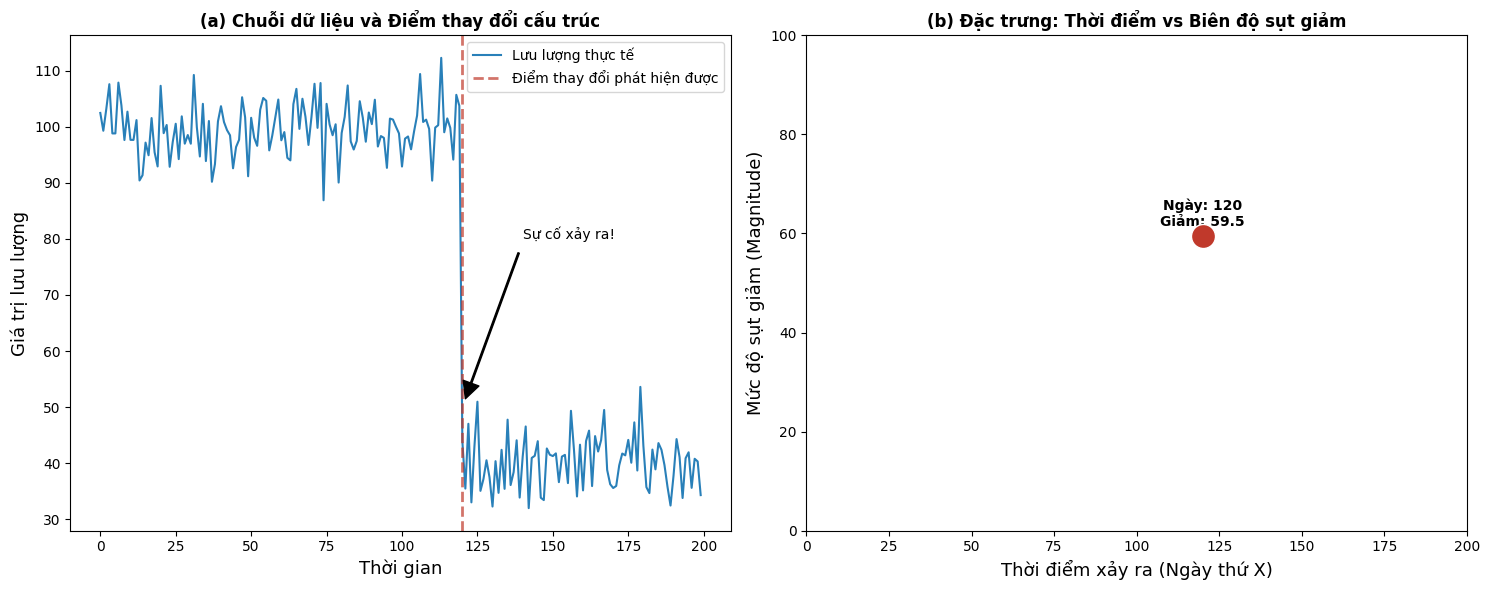

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. TẠO DỮ LIỆU CÓ ĐIỂM THAY ĐỔI (STRUCTURAL BREAK)
# ==========================================
np.random.seed(42)
t = np.arange(200)

# Giai đoạn 1: Ổn định (từ 0-120)
part1 = np.random.normal(100, 5, 120)
# Giai đoạn 2: Sụt giảm đột ngột (từ 120-200)
part2 = np.random.normal(40, 5, 80)

raw_data = np.concatenate([part1, part2])
change_point_true = 120

# ==========================================
# 2. TRÍCH XUẤT ĐẶC TRƯNG (CHANGE POINT)
# ==========================================
# Mô phỏng thuật toán phát hiện: Tìm điểm mà trung bình trượt thay đổi lớn nhất
mean_before = np.mean(part1)
mean_after = np.mean(part2)
magnitude_drop = mean_before - mean_after

# Đặc trưng trích xuất: [Thời điểm, Biên độ giảm]
features = [change_point_true, magnitude_drop]

# ==========================================
# 3. TRỰC QUAN HÓA
# ==========================================
plt.style.use('default')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# --- Biểu đồ A: Dữ liệu gốc và Điểm gãy ---
ax1.plot(t, raw_data, color='#2980B9', alpha=1.0, label='Lưu lượng thực tế')
ax1.axvline(x=change_point_true, color='#C0392B', linestyle='--', linewidth=2, label='Điểm thay đổi phát hiện được', alpha=0.7)
ax1.annotate('Sự cố xảy ra!', xy=(change_point_true, 50), xytext=(140, 80),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1))

ax1.set_title('(a) Chuỗi dữ liệu và Điểm thay đổi cấu trúc', fontweight='bold')
ax1.set_xlabel('Thời gian', fontsize=13)
ax1.set_ylabel('Giá trị lưu lượng', fontsize=13)
ax1.legend()

# --- Biểu đồ B: Không gian đặc trưng (Time vs Magnitude) ---
ax2.scatter(features[0], features[1], color='#C0392B', s=300, edgecolors='white', zorder=5)
ax2.set_title('(b) Đặc trưng: Thời điểm vs Biên độ sụt giảm', fontweight='bold')
ax2.set_xlabel('Thời điểm xảy ra (Ngày thứ X)', fontsize=13)
ax2.set_ylabel('Mức độ sụt giảm (Magnitude)', fontsize=13)

# Thêm nhãn số liệu trực tiếp vào điểm đặc trưng
ax2.text(features[0], features[1] + 2, f"Ngày: {features[0]}\nGiảm: {features[1]:.1f}",
         ha='center', fontweight='bold')

# Giới hạn trục để dễ nhìn
ax2.set_xlim(0, 200)
ax2.set_ylim(0, 100)

plt.tight_layout()

plt.savefig('Fig_06_ChangePoint.png', dpi=300, bbox_inches='tight')

try:
    from google.colab import files
    files.download('Fig_06_ChangePoint.png')
except ImportError:
    pass

plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

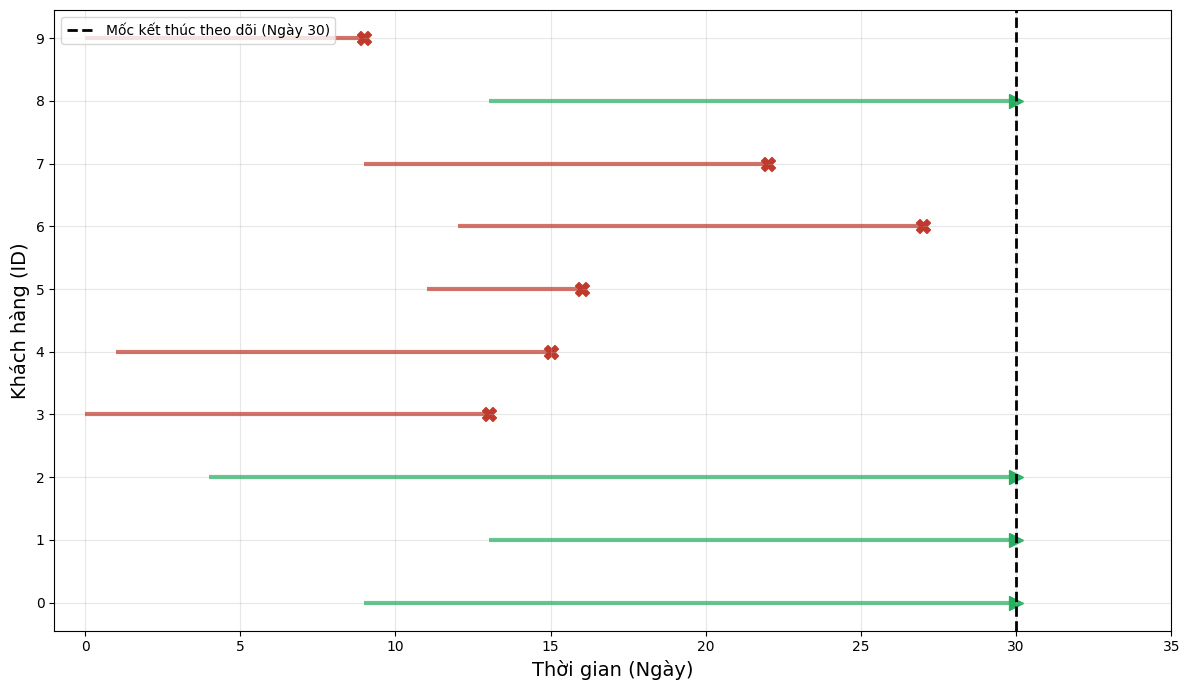

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. GIẢ LẬP DỮ LIỆU HÀNH TRÌNH KHÁCH HÀNG
# ==========================================
np.random.seed(10)
n_customers = 10
# Giả định mốc kết thúc quan sát là ngày 30 (Observation End)
obs_end = 30

# Ngày đăng ký (từ ngày 0 đến ngày 15)
start_days = np.random.randint(0, 15, n_customers)

# Thời gian ở lại thực tế (giả định nếu không có mốc kết thúc quan sát)
actual_durations = np.random.randint(5, 35, n_customers)

# Ngày "rời bỏ" thực tế
death_days = start_days + actual_durations

# --- LOGIC XỬ LÝ KIỂM DUYỆT (CENSORING) ---
# Nếu ngày rời bỏ > ngày kết thúc quan sát -> Bị kiểm duyệt (Censored)
observed_durations = []
event_observed = [] # 1 nếu rời bỏ, 0 nếu censored

for i in range(n_customers):
    if death_days[i] <= obs_end:
        # Sự kiện thực sự xảy ra trong thời gian theo dõi
        observed_durations.append(actual_durations[i])
        event_observed.append(1)
    else:
        # Sự kiện chưa xảy ra, khách hàng vẫn đang sử dụng tại ngày 30
        observed_durations.append(obs_end - start_days[i])
        event_observed.append(0)

# ==========================================
# 2. TRỰC QUAN HÓA
# ==========================================
plt.figure(figsize=(12, 7))
plt.style.use('default')
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

for i in range(n_customers):
    color = '#C0392B' if event_observed[i] == 1 else '#27AE60'
    label = 'Rời bỏ (Event)' if i == 0 and event_observed[i] == 1 else \
            'Đang dùng (Censored)' if i == 1 and event_observed[i] == 0 else ""

    # Vẽ đường hành trình từ ngày bắt đầu đến ngày kết thúc quan sát/rời bỏ
    plt.hlines(y=i, xmin=start_days[i], xmax=start_days[i] + observed_durations[i],
               color=color, linewidth=3, alpha=0.7)

    # Đánh dấu điểm kết thúc
    if event_observed[i] == 1:
        plt.scatter(start_days[i] + observed_durations[i], i, color=color, s=100, marker='X')
    else:
        plt.scatter(start_days[i] + observed_durations[i], i, color=color, s=100, marker='>')

# Đường thẳng mốc kết thúc quan sát
plt.axvline(x=obs_end, color='black', linestyle='--', linewidth=2, label='Mốc kết thúc theo dõi (Ngày 30)')

# plt.title('Minh họa Dữ liệu bị kiểm duyệt (Right-Censoring)', fontsize=15, fontweight='bold')
plt.xlabel('Thời gian (Ngày)', fontsize=14)
plt.ylabel('Khách hàng (ID)', fontsize=14)
plt.yticks(range(n_customers))
plt.legend(loc='upper left')
plt.xlim(-1, 35)
plt.tight_layout()

plt.savefig('Fig_07_Censored.png', dpi=500, bbox_inches='tight')

try:
    from google.colab import files
    files.download('Fig_07_Censored.png')
except ImportError:
    pass

plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

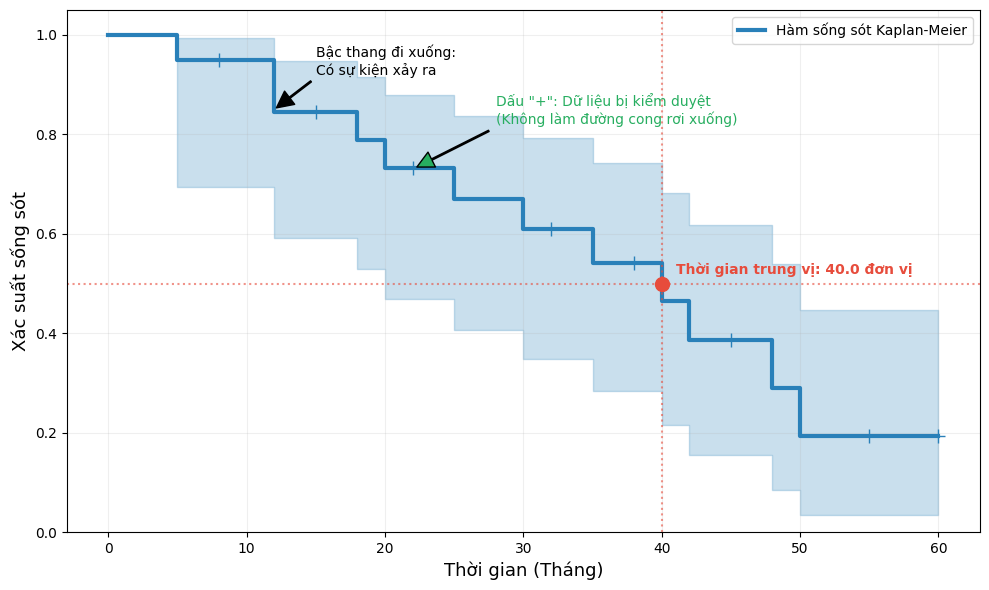

In [ ]:
!pip install -q lifelines
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

# ==========================================
# 1. TẠO DỮ LIỆU MÔ PHỎNG (Quy mô nhỏ để thấy rõ bậc thang)
# ==========================================
data = {
    'T': [5, 8, 12, 12, 15, 18, 20, 22, 25, 30, 32, 35, 38, 40, 42, 45, 48, 50, 55, 60],
    'E': [1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0]
    # 1: Sự kiện xảy ra (Rời bỏ), 0: Kiểm duyệt (Vẫn đang ở lại)
}
df_sim = pd.DataFrame(data)

# ==========================================
# 2. HUẤN LUYỆN MÔ HÌNH KM
# ==========================================
kmf = KaplanMeierFitter()
kmf.fit(df_sim['T'], event_observed=df_sim['E'])

# ==========================================
# 3. TRỰC QUAN HÓA
# ==========================================
plt.figure(figsize=(10, 6))
plt.style.use('default')

# Vẽ đường cong KM kèm dấu tick (+) tại các điểm bị kiểm duyệt
ax = kmf.plot_survival_function(
    linewidth=3,
    color='#2980B9',
    show_censors=True,
    censor_styles={'ms': 10, 'marker': '+'}, # Làm dấu + to rõ
    label="Hàm sống sót Kaplan-Meier"
)

# --- MINH HỌA CÁC ĐẶC ĐIỂM THEO GIÁO TRÌNH ---

# 1. Vẽ đường dóng cho Thời gian trung vị (Median Survival Time)
median_time = kmf.median_survival_time_
plt.axhline(y=0.5, color='#E74C3C', linestyle=':', alpha=0.6)
plt.axvline(x=median_time, color='#E74C3C', linestyle=':', alpha=0.6)
plt.scatter(median_time, 0.5, color='#E74C3C', s=100, zorder=5)

# 2. Chú thích "Bậc thang"
plt.annotate('Bậc thang đi xuống:\nCó sự kiện xảy ra',
             xy=(12, 0.85), xytext=(15, 0.92),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1))

# 3. Chú thích "Dấu cộng"
plt.annotate('Dấu "+": Dữ liệu bị kiểm duyệt\n(Không làm đường cong rơi xuống)',
             xy=(22, 0.73), xytext=(28, 0.82),
             arrowprops=dict(facecolor='#27AE60', shrink=0.05, width=1),
             color='#27AE60')

# 4. Chú thích "Thời gian trung vị"
plt.text(median_time + 1, 0.52, f'Thời gian trung vị: {median_time} đơn vị',
         fontweight='bold', color='#E74C3C')

# plt.title('Minh họa cấu trúc đường cong Kaplan-Meier (Dữ liệu giả lập)', fontsize=14, fontweight='bold')
plt.xlabel('Thời gian (Tháng)', fontsize=13)
plt.ylabel('Xác suất sống sót', fontsize=13)
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.2)
plt.legend()
plt.tight_layout()

plt.savefig('Fig_08_KM.png', dpi=500, bbox_inches='tight')

try:
    from google.colab import files
    files.download('Fig_08_KM.png')
except ImportError:
    pass

plt.show()